# DATA CREATION

In [1]:
import numpy as np
import pandas as pd
import json
from binn import BINN, BINNDataLoader, BINNTrainer, BINNExplainer

# ===== CLINICAL DATA GENERATION =====
def generate_clinical_data():
    """Generate clinical data matching SNP samples"""
    genotype_data = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    samples = genotype_data['samples'][:genotype_data['matrix'].shape[0]]
    n_samples = len(samples)
    
    np.random.seed(42)
    clinical_data = {
        'age': np.random.normal(65, 12, n_samples).clip(18, 95),
        'sex': np.random.choice(['Male', 'Female'], n_samples),
        'bmi': np.random.normal(26, 5, n_samples).clip(18, 45),
        'smoking': np.random.choice(['Never', 'Former', 'Current'], n_samples),
        'diabetes': np.random.choice([1, 0], n_samples, p=[0.15, 0.85]),
        'hypertension': np.random.choice([1, 0], n_samples, p=[0.25, 0.75]),
        'cholesterol': np.random.normal(200, 40, n_samples).clip(150, 300),
        'family_history': np.random.choice(['Yes', 'No'], n_samples)
    }
    
    # Create outcome
    risk_score = (0.1 + 0.2 * (clinical_data['age'] > 70) + 
                 0.15 * (clinical_data['sex'] == 'Male') +
                 0.1 * (clinical_data['smoking'] == 'Current') +
                 0.08 * clinical_data['diabetes'])
    outcome = np.random.binomial(1, np.clip(risk_score, 0.05, 0.8), n_samples)
    
    clinical_df = pd.DataFrame(clinical_data, index=samples)
    design_matrix = pd.DataFrame({
        'sample': samples,
        'target': outcome,
        'group': ['high_risk' if x == 1 else 'low_risk' for x in outcome]
    })
    return clinical_df, design_matrix

In [ ]:


<!DOCTYPE html>
<html>
<head>
    <title>Section 1: Clinical Data Generation</title>
    <style>
        body { font-family: Arial; padding: 20px; background: #f5f5f5; }
        .container { max-width: 800px; margin: 0 auto; background: white; padding: 30px; border-radius: 10px; }
        h1 { color: #333; border-bottom: 3px solid #007acc; padding-bottom: 10px; }
        .code { background: #2d3748; color: #e2e8f0; padding: 15px; border-radius: 5px; font-family: monospace; margin: 15px 0; }
        .function { background: #f8f9fa; padding: 15px; margin: 10px 0; border-left: 4px solid #007acc; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Section 1: Clinical Data Generation</h1>
        
        <div class="function">
            <h3>generate_clinical_data()</h3>
            <p>Creates clinical variables matching SNP samples</p>
        </div>
        
        <div class="code">
def generate_clinical_data():
    genotype_data = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    samples = genotype_data['samples'][:genotype_data['matrix'].shape[0]]
    n_samples = len(samples)
    
    clinical_data = {
        'age': np.random.normal(65, 12, n_samples).clip(18, 95),
        'sex': np.random.choice(['Male', 'Female'], n_samples),
        'bmi': np.random.normal(26, 5, n_samples).clip(18, 45),
        'smoking': np.random.choice(['Never', 'Former', 'Current'], n_samples),
        'diabetes': np.random.choice([1, 0], n_samples, p=[0.15, 0.85])
    }
    
    return clinical_df, design_matrix
        </div>
        
        <div class="function">
            <h3>encode_clinical_data()</h3>
            <p>One-hot encode categorical, standardize continuous</p>
        </div>
        
        <div class="code">
def encode_clinical_data(clinical_df):
    encoded = pd.DataFrame(index=clinical_df.index)
    
    for col in clinical_df.columns:
        if clinical_df[col].dtype == 'object':
            dummies = pd.get_dummies(clinical_df[col], prefix=col)
            encoded = pd.concat([encoded, dummies], axis=1)
        else:
            encoded[col] = (clinical_df[col] - clinical_df[col].mean()) / clinical_df[col].std()
    
    return encoded
        </div>
    </div>
</body>
</html>

# Preprocessing

In [2]:
def encode_clinical_data(clinical_df):
    """One-hot encode categorical, standardize continuous"""
    encoded = pd.DataFrame(index=clinical_df.index)
    
    for col in clinical_df.columns:
        if clinical_df[col].dtype == 'object':
            dummies = pd.get_dummies(clinical_df[col], prefix=col)
            encoded = pd.concat([encoded, dummies], axis=1)
        else:
            encoded[col] = (clinical_df[col] - clinical_df[col].mean()) / clinical_df[col].std()
    return encoded


# Data Merge

In [3]:
def create_combined_datamatrix():
    """Combine SNP + clinical data"""
    # Load SNP data
    genotype_data = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    genotype_matrix = genotype_data['matrix']
    samples = genotype_data['samples'][:genotype_matrix.shape[0]]
    
    with open('snp_index.json') as f:
        snp_index = json.load(f)
    snp_names = list(snp_index.keys())
    
    snp_df = pd.DataFrame(genotype_matrix.T, index=snp_names, columns=samples)
    
    # Add clinical data
    clinical_df, design_matrix = generate_clinical_data()
    clinical_encoded = encode_clinical_data(clinical_df)
    
    # Combine
    combined_df = pd.concat([snp_df, clinical_encoded.T], axis=0)
    combined_df.reset_index(inplace=True)
    combined_df.rename(columns={'index': 'Protein'}, inplace=True)
    
    print(f"Combined: {len(snp_names)} SNPs + {len(clinical_encoded.columns)} clinical features")
    return combined_df, design_matrix, clinical_encoded.columns.tolist()


# CONNECTIVITY EXTENSION

In [4]:
def create_extended_connectivity(clinical_features):
    """Extend SNP connectivity with clinical pathways"""
    # Load existing SNP connectivity
    mapping_df, pathways_df = load_existing_connectivity()
    
    # Define clinical pathways
    clinical_pathways = {
        'DEMOGRAPHICS': ['age', 'sex_Male', 'sex_Female'],
        'LIFESTYLE': ['bmi', 'smoking_Never', 'smoking_Former', 'smoking_Current'],
        'COMORBIDITIES': ['diabetes', 'hypertension'],
        'FAMILY_RISK': ['family_history_Yes', 'family_history_No'],
        'BIOMARKERS': ['cholesterol']
    }
    
    # Create clinical mappings
    clinical_mapping = []
    clinical_pathways_data = []
    
    for feature in clinical_features:
        clinical_mapping.append({'input': feature, 'translation': feature})
        
        # Assign to pathway
        assigned = False
        for pathway, features in clinical_pathways.items():
            if any(f in feature for f in features):
                clinical_pathways_data.append({'source': feature, 'target': pathway})
                assigned = True
                break
        
        if not assigned:
            clinical_pathways_data.append({'source': feature, 'target': 'CLINICAL_OTHER'})
    
    # Combine with existing
    extended_mapping = pd.concat([mapping_df, pd.DataFrame(clinical_mapping)], ignore_index=True)
    extended_pathways = pd.concat([pathways_df, pd.DataFrame(clinical_pathways_data)], ignore_index=True)
    
    return extended_mapping, extended_pathways

# LOADING DATA

In [5]:
def load_existing_connectivity():
    """Load existing SNP connectivity"""
    layer1 = pd.read_pickle('connectivity_layer_1.pkl')
    
    mapping_data = []
    for snp in layer1.index:
        for target in layer1.columns:
            if layer1.loc[snp, target] > 0:
                mapping_data.append({'input': snp, 'translation': target})
    
    layer2 = pd.read_pickle('connectivity_layer_2.pkl')
    pathway_data = []
    for source in layer2.index:
        for target in layer2.columns:
            if layer2.loc[source, target] > 0:
                pathway_data.append({'source': source, 'target': target})
    
    return pd.DataFrame(mapping_data), pd.DataFrame(pathway_data)

# TRAINING

In [6]:
def train_snp_clinical_binn():
    """Train BINN with SNP + Clinical data"""
    print("Training SNP + Clinical BINN...")
    
    # Prepare data
    combined_datamatrix, design_matrix, clinical_features = create_combined_datamatrix()
    mapping, pathways = create_extended_connectivity(clinical_features)
    
    # Initialize BINN
    binn = BINN(
        data_matrix=combined_datamatrix,
        mapping=mapping,
        pathways=pathways,
        device="cpu",
        n_outputs=2,
        n_layers=3,
        activation="tanh",
        input_col="input",
        target_col="target",
        entity_col="Protein",
        source_col="source",
        translation_col="translation"
    )
    
    # Create dataloaders
    binn_dataloader = BINNDataLoader(binn)
    dataloaders = binn_dataloader.create_dataloaders(
        data_matrix=combined_datamatrix,
        design_matrix=design_matrix,
        feature_column="Protein",
        group_column="group",
        sample_column="sample",
        batch_size=16,
        validation_split=0.2
    )
    
    # Train
    trainer = BINNTrainer(binn)
    trainer.fit(dataloaders=dataloaders, num_epochs=15)
    
    print("✅ Training complete!")
    return binn, trainer, dataloaders


# EXPLANATION

In [7]:
def explain_snp_clinical_binn(binn, dataloaders):
    """Generate explanations for trained model"""
    explainer = BINNExplainer(binn)
    explanations = explainer.explain_single(dataloaders, normalization_method="fan")
    explanations.to_csv("snp_clinical_explanations.csv", index=False)
    
    print(f"Generated {len(explanations)} explanations")
    return explanations


# VISUALISATION

In [11]:
def visualize_snp_clinical_results(explanations):
    """Visualize SNP + Clinical BINN results"""
    from binn.plot.network import visualize_binn
    import matplotlib.pyplot as plt
    
    # Network visualization
    plt = visualize_binn(
        explanations,
        top_n={"0": 15, "1": 20, "2": 8},
        plot_size=(16, 12),
        node_size_scaling=400,
        edge_width=2
    )
    plt.title("SNP + Clinical BINN Network")
    plt.show()
    
    # Feature importance by type
    snp_features = explanations[~explanations['source_node'].str.contains('age|sex|bmi|smoking|diabetes|hypertension|cholesterol|family', na=False)]
    clinical_features = explanations[explanations['source_node'].str.contains('age|sex|bmi|smoking|diabetes|hypertension|cholesterol|family', na=False)]
    
    print(f"SNP connections: {len(snp_features)}")
    print(f"Clinical connections: {len(clinical_features)}")
    
    # Top clinical features
    if len(clinical_features) > 0:
        top_clinical = clinical_features.nlargest(5, 'importance')
        print("\nTop Clinical Features:")
        for _, row in top_clinical.iterrows():
            print(f"  {row['source_node']}: {row['importance']:.4f}")
    
    return plt

# MAIN EXECUTION

Training SNP + Clinical BINN...
Combined: 100 SNPs + 12 clinical features

[INFO] BINN is on device: cpu
Mapping group labels: {'high_risk': 0, 'low_risk': 1}
[Epoch 1/15] Train Loss: 0.7407, Train Accuracy: 0.6042
[Epoch 1/15] Val Loss: 0.6912, Val Accuracy: 0.7000
[Epoch 2/15] Train Loss: 0.7888, Train Accuracy: 0.5625
[Epoch 2/15] Val Loss: 0.6896, Val Accuracy: 0.7000
[Epoch 3/15] Train Loss: 0.7588, Train Accuracy: 0.5625
[Epoch 3/15] Val Loss: 0.6882, Val Accuracy: 0.7000
[Epoch 4/15] Train Loss: 0.7254, Train Accuracy: 0.5833
[Epoch 4/15] Val Loss: 0.6867, Val Accuracy: 0.7000
[Epoch 5/15] Train Loss: 0.7045, Train Accuracy: 0.6042
[Epoch 5/15] Val Loss: 0.6851, Val Accuracy: 0.7000
[Epoch 6/15] Train Loss: 0.7491, Train Accuracy: 0.6250
[Epoch 6/15] Val Loss: 0.6838, Val Accuracy: 0.7000
[Epoch 7/15] Train Loss: 0.7477, Train Accuracy: 0.5208
[Epoch 7/15] Val Loss: 0.6812, Val Accuracy: 0.7000
[Epoch 8/15] Train Loss: 0.7261, Train Accuracy: 0.5833
[Epoch 8/15] Val Loss: 0.6791

/opt/anaconda3/lib/python3.12/site-packages/binn/model/dataloader.py:88: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = pd.concat(X_list).fillna(0).to_numpy()


Generated 2154 explanations


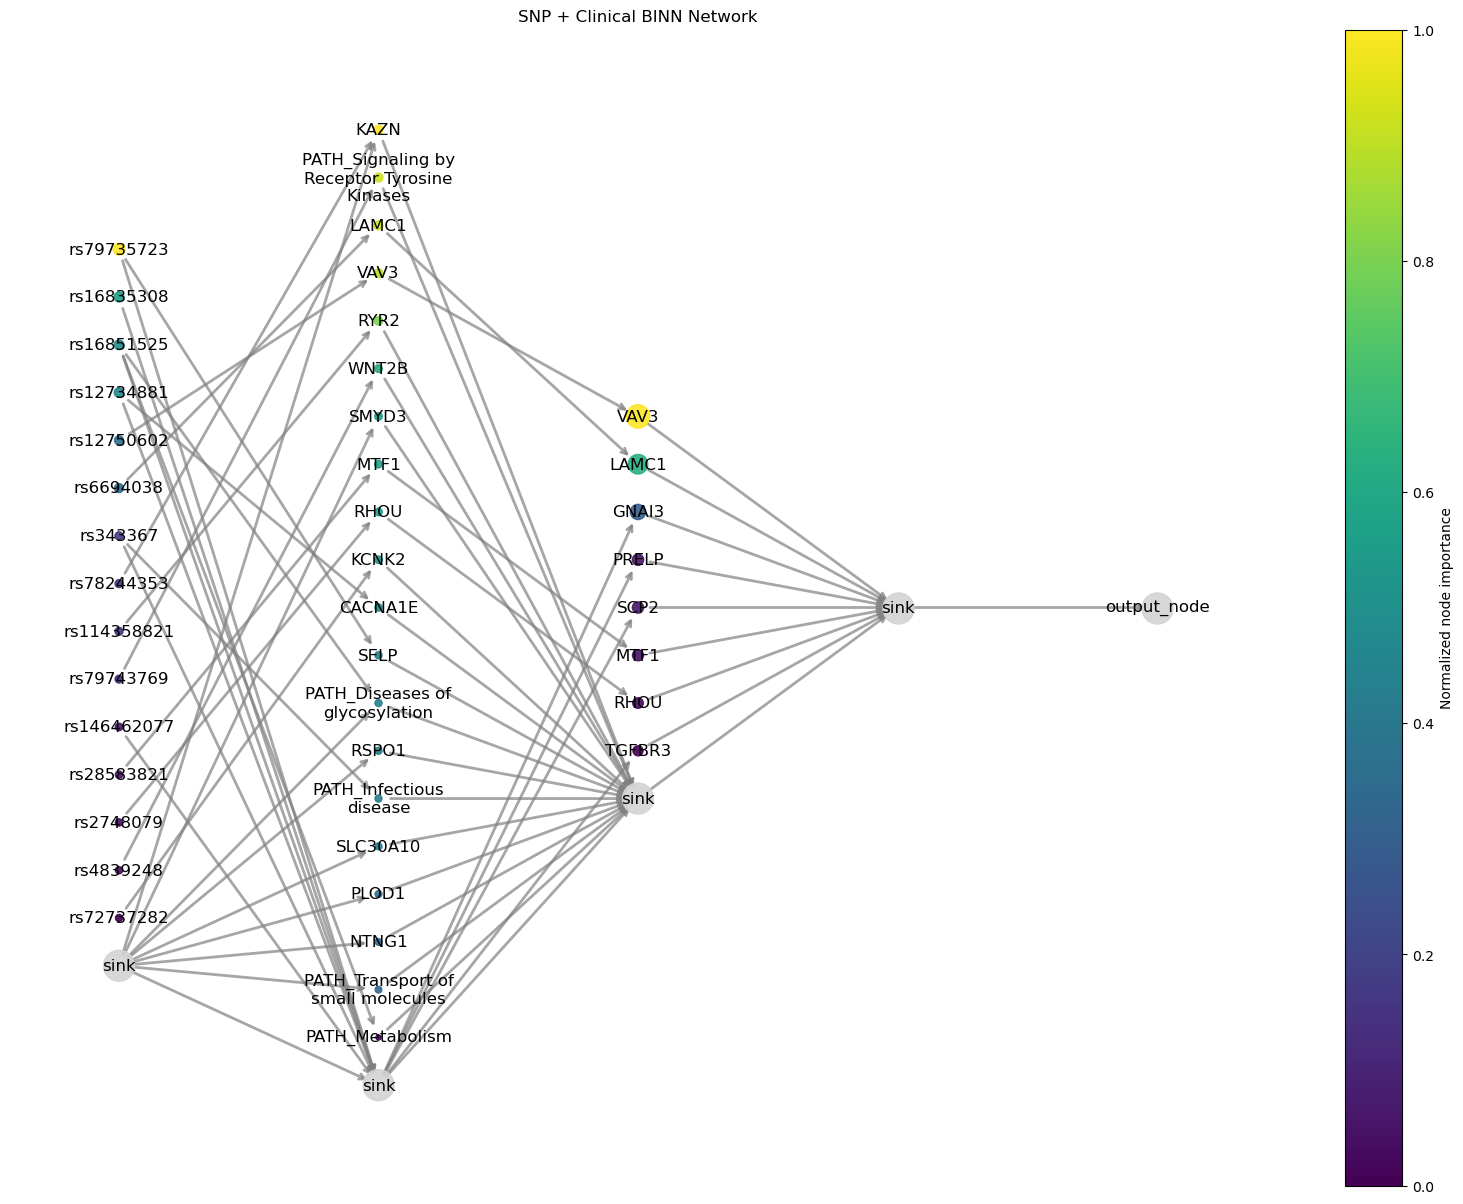

SNP connections: 2058
Clinical connections: 96

Top Clinical Features:
  Synthesis of bile acids and bile salts via 7alpha-hydroxycholesterol: 0.0252
  Developmental Cell Lineages: 0.0205
  Developmental Lineage of Pancreatic Ductal Cells: 0.0182
  Signaling by TGFB family members: 0.0174
  Developmental Lineage of Pancreatic Ductal Cells: 0.0158


In [12]:
if __name__ == '__main__':
    # Train model
    binn, trainer, dataloaders = train_snp_clinical_binn()
    
    # Generate explanations
    explanations = explain_snp_clinical_binn(binn, dataloaders)

    # Visualize results
    visualize_snp_clinical_results(explanations)